# Logistic Regression Baseline Model
This code implements the logistic regression baseline model on our dataset. Either the full dataset or the 200 patient subset may be loaded and used for model training and evaluation. After fitting the model to our training data, we generate predictions on the validation set. Finally, we evaluate the model using various accuracy metrics.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, auc, roc_curve, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, average_precision_score, ConfusionMatrixDisplay, classification_report
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import GridSearchCV

## Load in training, validation, and testing datasets
First we load the data into pandas dataframes. We follow this by refining the dataset to our needs, such as by excluding sparse features, normalizing, and filling in empty values.

### Full dataset

In [10]:
path = '../../Data/Full_Dataset/'

train_df = pd.read_parquet(path+'sepsis_dataset_padded_masked_train.parquet')
val_df = pd.read_parquet(path+'sepsis_dataset_padded_masked_val.parquet')
test_df = pd.read_parquet(path+'sepsis_dataset_padded_masked_test.parquet')

Only necessary for full dataset: rename the timestep column for consistency and mask out the padding, since this is not necessary for the baseline model in this notebook.

In [11]:
# Rename column to ensure consistency
train_df.rename(columns={'Step': 'Hour'}, inplace=True)
val_df.rename(columns={'Step': 'Hour'}, inplace=True)
test_df.rename(columns={'Step': 'Hour'}, inplace=True)

# Mask out padding (not needed for baseline)
train_df = train_df[train_df['Mask']==1]
val_df = val_df[val_df['Mask']==1]
test_df = test_df[test_df['Mask']==1]

### 200 patient subset

In [ ]:
# path = '../../Data/200_Pt_Subset/'

# train_df = pd.read_csv(path+'subset_train.csv')
# val_df = pd.read_csv(path+'subset_val.csv')
# test_df = pd.read_csv(path+'subset_test.csv')

### Refine dataset
We only include relevant columns.

In [12]:
# Only include relevant features
features = ['PatientID', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
           #'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'PaCO2',
            'pH', 'SaO2', 'AST', 'BUN',
            #'Alkalinephos',
            'Calcium', 'Chloride', 'Creatinine', 'Glucose',
            #'Bilirubin_direct', 'Lactate',
            'Magnesium', 'Phosphate', 'Potassium',
            #'Bilirubin_total', 'TroponinI', 'PTT',
             'Hct', 'Hgb', 'WBC',
            #'Fibrinogen',
            'Platelets', 'Age', 'Gender',
            'Unit1', 'Unit2',
            'HospAdmTime', 'ICULOS', 'SepsisLabel']
train_df = train_df[features]
val_df = val_df[features]
test_df = test_df[features]

Define all features that we want to scale. Make a copy of the dataframe to normalize. Fit the standard scaler on training data. Obtain scaled training and valid data using transform.

In [13]:
float_feats = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
            'pH', 'SaO2', 'AST', 'BUN',
            'Calcium', 'Chloride', 'Creatinine', 'Glucose',
            'Magnesium', 'Phosphate', 'Potassium',
             'Hct', 'Hgb', 'WBC',
            'Platelets']

train_df_norm = train_df.copy()
val_df_norm = val_df.copy()
test_df_norm = test_df.copy()

# define scaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaler.fit(train_df_norm[float_feats])
train_df_norm[float_feats] = scaler.transform(train_df_norm[float_feats])
val_df_norm[float_feats] = scaler.transform(val_df_norm[float_feats])
test_df_norm[float_feats] = scaler.transform(test_df_norm[float_feats])

Replace NaNs with 0 and verify.

In [14]:
# Replace NaNs with 0
train_df_norm_filled = train_df_norm.fillna(0)
val_df_norm_filled = val_df_norm.fillna(0)
test_df_norm_filled = test_df_norm.fillna(0)

# check data missingness
print('train data has missing values:', train_df_norm_filled.isnull().sum().sum() != 0)
print('valid data has missing values:', val_df_norm_filled.isnull().sum().sum() != 0)
print('test data has missing values:', test_df_norm_filled.isnull().sum().sum() != 0)

train data has missing values: False
valid data has missing values: False
test data has missing values: False


## Restructure data
Define a function to get predictor/label arrays from dataframes.

In [15]:
def get_X_y(df, features_of_interest=None):
  """
  Restructure dataframe of patient time-series data into predictor and label arrays

  Parameters:
  ----------
  df : patient ICU data dataframe
  features_of_interest : features you want to include in final model; if None, includes all
                         features except PatientID, Hour, and SepsisLabel

  Returns:
  ----------
      X: np.ndarray of shape [num_total_timesteps, num_features]
      y: np.ndarray of shape [num_total_timesteps,]
  """

  # Define which columns to use
  if features_of_interest is None:
      exclude_cols = ['PatientID', 'Hour', 'SepsisLabel']
      features_of_interest = [col for col in df.columns if col not in exclude_cols]

  # Create X array of predictors, y array of sepsis labels
  X = np.array(df[features_of_interest].values)
  y = df['SepsisLabel'].values

  return X, y

Pass the dataframes into the function and get the predictor and label arrays.

In [16]:
# Normalized, filled train/val/test data:
X_train, y_train = get_X_y(train_df_norm_filled)
print("X train shape:", X_train.shape)  # (num_total_timesteps, num_features)
print("y train shape:", y_train.shape)  # (num_total_timesteps,)

X_val, y_val = get_X_y(val_df_norm_filled)
print("X val shape:", X_val.shape)  # (num_total_timesteps, num_features)
print("y val shape:", y_val.shape)  # (num_total_timesteps,)

X_test, y_test = get_X_y(test_df_norm_filled)
print("X train shape:", X_test.shape)  # (num_total_timesteps, num_features)
print("y train shape:", y_test.shape)  # (num_total_timesteps,)

X train shape: (883508, 28)
y train shape: (883508,)
X val shape: (292487, 28)
y val shape: (292487,)
X train shape: (293305, 28)
y train shape: (293305,)


## Logistic Regression Model
(from https://github.com/sedab/EarlySepsisPrediction/blob/master/models/baseline/baseline_model_LR.ipynb)

Create a LogisticRegression object logreg and fit the training data.

In [17]:
logreg = linear_model.LogisticRegression(C=10, solver='saga', max_iter=1000)
logreg.fit(X_train, y_train)

c:\Users\lmwhe\anaconda3\envs\erdos_spring_2025\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=10, max_iter=1000, solver='saga')

Calculate validation predictions and verify that model doesn't predict all 0s

In [18]:
y_pred = logreg.predict(X_val)
print(np.unique(y_pred))

[0 1]


## Model Test Performance
Evaluate various accuracy metrics from the model predictions on the test set. We calculate precision/recall scores, F1 score, AUROC and AUPRC, and overall accuracy. We also display the confusion matrix and plot the ROC and PR curves.




In [23]:
# Allows us to easily switch between evaluating the model on the validation or test set:

# Validation set:
# X_eval = X_val 
# y_true = y_val

# Test set:
X_eval = X_test
y_true = y_test

In [ ]:
# predictions
y_pred = logreg.predict(X_eval)

# prediction probabilities
y_pred_probas = logreg.predict_proba(X_eval)[:,1]

[0 1]


Print the accuracy metrics, including f1 score, precision, recall, AUROC, AUPRC, and overall.

In [ ]:
def get_accuracy(y_true, y_pred, y_pred_probas):
  fpr, tpr, _ = roc_curve(y_true, y_pred_probas)
  precision, recall, _ = precision_recall_curve(y_true, y_pred_probas)

  print('f1 score {0:.4f}:'.format(f1_score(y_true, y_pred)))
  print('precision {0:.4f}:'.format(precision_score(y_true, y_pred)))
  print('recall {0:.4f}:'.format(recall_score(y_true, y_pred)))
  print('AUPRC {0:.4f}:'.format(auc(recall, precision)))
  print('AUROC {0:.4f}:'.format(auc(fpr, tpr)))
  print('Overall Acc {0:.4f}:'.format(np.mean(y_pred == y_true)))

In [34]:
get_accuracy(y_true, y_pred, y_pred_probas)

f1 score 0.0185:
precision 0.2318:
recall 0.0096:
AUPRC 0.0499:
AUROC 0.6643:
Overall Acc 0.9805:


Display the confusion matrix

In [35]:
def confusion_mat(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
  disp = ConfusionMatrixDisplay(cm, display_labels=['Non-septic', 'Septic'])
  disp.plot()

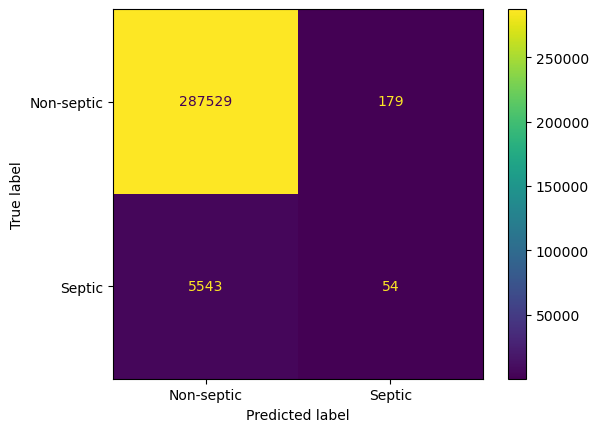

In [36]:
confusion_mat(y_true, y_pred)

Visualisation of ROC and precision/recall curves

In [37]:
def visualize_curves(y_true, y_pred_probas):
  # Compute metrics
  fpr, tpr, _ = roc_curve(y_true, y_pred_probas)
  auroc = roc_auc_score(y_true, y_pred_probas)

  precision, recall, _ = precision_recall_curve(y_true, y_pred_probas)
  auprc = average_precision_score(y_true, y_pred_probas)

  # Plot side-by-side
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # ROC curve
  axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auroc:.3f}')
  axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
  axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
  axes[0].set_xlabel('False Positive Rate')
  axes[0].set_ylabel('True Positive Rate')
  axes[0].legend(loc='lower right')
  axes[0].grid(alpha=0.3)

  # Precision-Recall curve
  axes[1].plot(recall, precision, color='green', lw=2, label=f'AP = {auprc:.3f}')
  axes[1].set_title('Precision–Recall Curve')
  axes[1].set_xlabel('Recall')
  axes[1].set_ylabel('Precision')
  axes[1].legend(loc='lower left')
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()


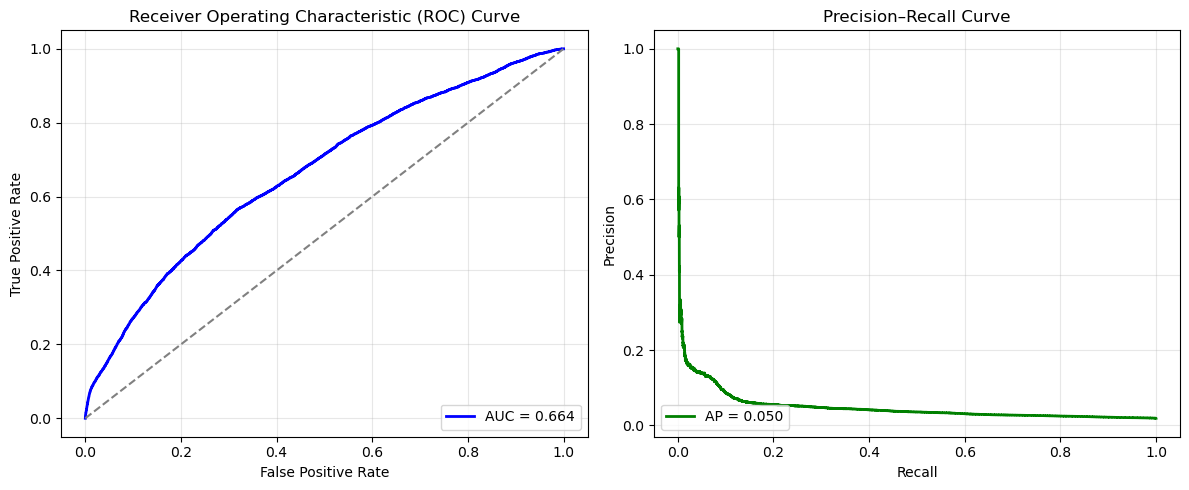

In [38]:
visualize_curves(y_true, y_pred_probas)

## Interpreting the Weight Vector
Create a stem plot of the coefficients, W in the logistic regression model. The most significant features have larger values in the stem plot.

<StemContainer object of 3 artists>

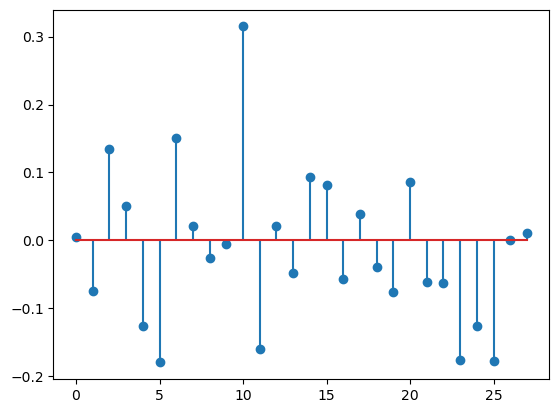

In [39]:
W = logreg.coef_.ravel()
plt.stem(W)

In [40]:
end = len(W)

X_features = features[2:-1]
wts = np.sort(np.abs(W))
inds = np.argsort(np.abs(W))

# Header
print("Most significant features:\n")
print(f"{'Rank':<4} | {'Feature Name':<15} | {'|Weight|':>10}")
print("-" * 35)

# Print rows (from largest to smallest weight)
for k in range(1, end + 1):
    i = inds[-k]
    print(f"{k:<4} | {X_features[i]:<15} | {wts[-k]:>10.4f}")


Most significant features:

Rank | Feature Name    |   |Weight|
-----------------------------------
1    | BUN             |     0.3150
2    | DBP             |     0.1799
3    | Unit2           |     0.1771
4    | Gender          |     0.1769
5    | Calcium         |     0.1603
6    | Resp            |     0.1507
7    | Temp            |     0.1347
8    | Unit1           |     0.1265
9    | MAP             |     0.1258
10   | Glucose         |     0.0933
11   | WBC             |     0.0865
12   | Magnesium       |     0.0809
13   | Hgb             |     0.0753
14   | O2Sat           |     0.0750
15   | Age             |     0.0629
16   | Platelets       |     0.0610
17   | Phosphate       |     0.0573
18   | SBP             |     0.0499
19   | Creatinine      |     0.0486
20   | Hct             |     0.0390
21   | Potassium       |     0.0387
22   | SaO2            |     0.0265
23   | pH              |     0.0218
24   | Chloride        |     0.0216
25   | ICULOS          |     0.0114


## Hyperparameter Tuning
Identify hyperparameters for tuning. Create lists of values for these hyperparameters. Use GridSearchCV to select the optimal model.

In [19]:
# create a logistic regression model
logreg = linear_model.LogisticRegression(solver='saga', max_iter=1000)

# create hyperparameter search space
# create regularization penalty space
penalty = ['l1', 'l2']

# create regularization hyperparameter space
C = np.logspace(-1, 4, 10)

# create hyperparameter options
hyperparameters = dict(C=C, penalty=penalty)

Create GridSearchCV and fit the best model.

In [20]:
# create grid search using 5-fold cross validation
clf = GridSearchCV(logreg, hyperparameters, cv=5, verbose=0)

# best model
best_model = clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Show the hyperparameters of the best model.

In [22]:
best_model.best_params_

{'C': np.float64(0.1), 'penalty': 'l1'}